In [ ]:
# load data

import os
import pandas as pd, numpy as np
import sys
sys.path.append('../../../')
from polygene.model.model import load_trained_model

EMBEDDINGS_DIR = '/media/lleger/LaCie/mit/disease_vector/'
SEEDS_EXPERIMENT_PATH = '/media/lleger/LaCie/mit/disease_vector/seeds_experiment/'
SAVE = False
model, tokenizer = load_trained_model('../../../runs/gesam_polygene_run_4/', checkpoint_n=-1)

df_list = []
for file in [EMBEDDINGS_DIR + f for f in os.listdir(EMBEDDINGS_DIR) if 'embeddings_part' in f]:
    embeddings = pd.read_pickle(file)
    df_list.append(pd.DataFrame.from_dict({"embeddings": embeddings[0].tolist(), 'disease':embeddings[2][:,tokenizer.phenotypic_types.index('disease')],
                                           'disease_pred': embeddings[1][:,tokenizer.phenotypic_types.index('disease')]}))
embedding_df = pd.concat(df_list)

centroids_df = pd.DataFrame(embedding_df.groupby('disease').apply(lambda group: pd.Series({"centroid": np.array(group['embeddings'].tolist()).mean(axis=0)})).reset_index())

import umap
umap_path = EMBEDDINGS_DIR + 'umap.pkl'
if not os.path.exists(path=umap_path):
    reducer = umap.UMAP(spread=2, min_dist=1.5, n_neighbors=30, random_state=3,)
    low_dim_embeddings = reducer.fit_transform(np.array(embedding_df['embeddings'].tolist()))
    labels = embedding_df['disease'].apply(lambda x: ' '.join([word.capitalize() for word in x[1:-1].split('_')]))
    labels = pd.Categorical(labels)
    df = pd.DataFrame({'UMAP1': low_dim_embeddings[:,0], 'UMAP2': low_dim_embeddings[:,1], 'Phenotype': labels})
    df.to_pickle(umap_path)
else: df = pd.read_pickle(umap_path)

/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/tmp/ipykernel_1623478/679864358.py:35: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  row_link = linkage(1-x, method=method)
/tmp/ipykernel_1623478/679864358.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


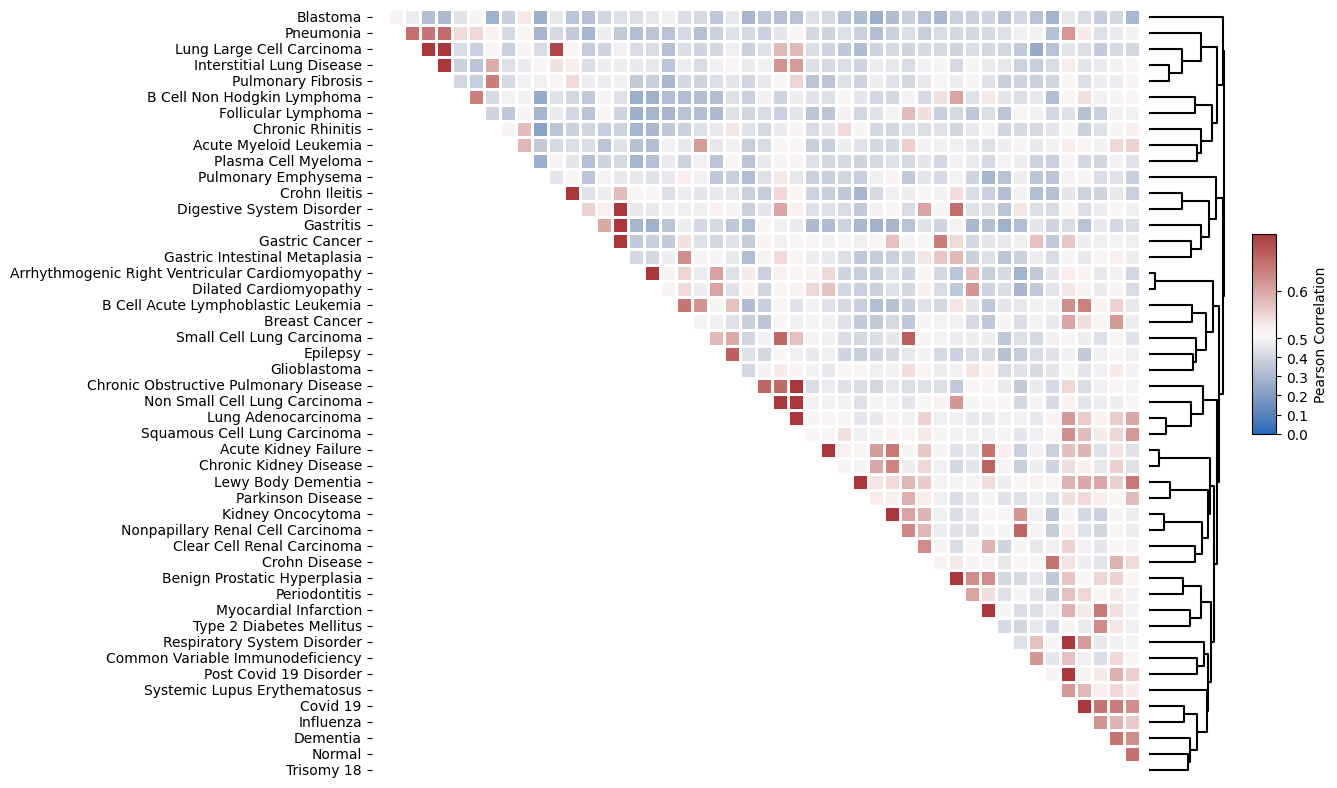

In [22]:
esthetic_disease_labels = {'Arrhythmogenic Right Ventricular Cardiomyopathy': 'Arrhythmogenic Cardiomyopathy', 'Common Variable Immunodeficiency': 'CV Immunodeficiency', 
                           'B Cell Non Hodgkin Lymphoma': 'B Cell Lymphoma'}
# Correlation Matrix
import torch
from polygene.data_utils.tokenization import normalise_str

from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram, fcluster
import numpy as np, seaborn as sns, matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def upper_triangle_heatmap_dendro_right(data = "vocab", method='average', cmap='vlag', figsize=(8,8), metric="pearson"):
    if data != "vocab":
        diseases = centroids_df['disease'].tolist()
        disease_ids = [tokenizer.token_to_id_map[normalise_str(token)] for token in centroids_df['disease']]
        disease_embedding_mat = np.array(centroids_df['centroid'].tolist())
    else:
        diseases = [normalise_str(token) for token in tokenizer.phenotypic_tokens_map['disease']]
        disease_ids = [tokenizer.token_to_id_map[normalise_str(token)] for token in tokenizer.phenotypic_tokens_map['disease']]
        disease_embedding_mat = model.embeddings.token_value_embeddings(torch.tensor(disease_ids, device=model.device)).cpu().detach().numpy()
    for disease_to_rmv in ['[hypersensitivity_pneumonitis]', '[kidney_benign_neoplasm]', '[pulmonary_sarcoidosis]', '[non_specific_interstitial_pneumonia]', '[adenocarcinoma]',
                           '[alzheimer_disease]']:
        idx = diseases.index(disease_to_rmv) if disease_to_rmv in diseases else -1
        if idx == -1:
            continue
        diseases.pop(idx)
        disease_embedding_mat = np.delete(disease_embedding_mat, idx, axis=0)
    
    if metric == "pearson":
        x = np.corrcoef(disease_embedding_mat)
    elif metric == "cosine":
        x = cosine_similarity(disease_embedding_mat)
    else:
        raise ValueError("metric must be 'pearson' or 'cosine'")
    row_link = linkage(1-x, method=method)
    order = leaves_list(row_link)
    corr = x[np.ix_(order, order)].copy()
    corr[np.tril_indices_from(corr, 0)] = np.nan

    fig = plt.figure(figsize=figsize, dpi=300 if SAVE else 100)
    gs = fig.add_gridspec(1, 3, width_ratios=(10, 1, 0.5), wspace=0)
    ax_heat = fig.add_subplot(gs[0, 0])
    ax_dendro = fig.add_subplot(gs[0, 1])
    #vmin, vmax = 0., 0.7
    #center = 3*(vmin + vmax) / 4
    vmin, vmax = 0, 0.7
    center = 3*(vmin + vmax) / 4

    #### CUSTOM IDENTIFIED CLUSTERS 
    custom_clusters=False
    if custom_clusters:
        from matplotlib.patches import Rectangle
        cut_height = 1
        cluster_ids = fcluster(row_link, cut_height, criterion='distance')
        cluster_ids = cluster_ids[order]  # reorder to match heatmap

        for cluster_label in np.unique(cluster_ids):
            if cluster_label in [4, 10, 9, 6, 2, 5, 11]: continue 
            indices = np.where(cluster_ids == cluster_label)[0]
            i_min, i_max = indices.min(), indices.max()
            size = i_max - i_min + 1

            rect = Rectangle((i_min, i_min), size, size, fill=False, edgecolor="k", linewidth=3)
            ax_heat.add_patch(rect)
            name = {1: 'Lung', 3: 'Gastric', 7: 'Kidney', 8: 'Lung \nCancer'}[cluster_label]
            offset_x = -0.2 if cluster_label != 8 else -size/2 - size/4
            offset_y = 1 if cluster_label != 8 else size/2 + size/4
            offset_xy = 0 
            ax_heat.text(i_min + size/2 + offset_xy + offset_x, i_min + size/2 + offset_xy + offset_y, f"{name}", 
                            color="k", ha="center", va="center", rotation=-45, fontsize=10, weight="bold")
        ### OK

    norm = TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)
    labels = [' '.join([w.capitalize() for w in l[1:-1].split('_')]) for l in diseases]
    #labels = [esthetic_disease_labels.get(l, l) for l in labels]
    heatmap = sns.heatmap(
        corr, ax=ax_heat, cmap=cmap, norm=norm, square=True,
        xticklabels=False,
        yticklabels=(np.asarray(labels)[order] if labels is not None else True),
        mask=np.isnan(corr), cbar=False,
        lw=1, zorder=0)
    ax_heat.set_facecolor('white')
    ax_heat.tick_params(axis='y', labelsize=10)
    cbar_ax = fig.add_axes([0.975, 0.45, 0.02, 0.25])  # [left, bottom, width, height]
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    #sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Pearson Correlation' if metric=="pearson" else 'Cosine Similarity')

    dendrogram(row_link, orientation='right', color_threshold=0, above_threshold_color='k', no_labels=True, ax=ax_dendro)
    for spine in ax_dendro.spines.values(): spine.set_visible(False)
    ax_dendro.axis('off')
    ax_dendro.invert_yaxis()
    plt.tight_layout()
    #plt.savefig('../figures/figure2/correlation_matrix.png', dpi=300, bbox_inches = 'tight', transparent=True)
    if SAVE: plt.savefig('../figures/figure2_correlation_matrix.svg', dpi=300, transparent=True)
    plt.show()
    return order, corr, (fig, ax_heat, ax_dendro)

r = upper_triangle_heatmap_dendro_right(data="v", figsize=(12,8), method="average", metric="pearson", cmap="vlag")

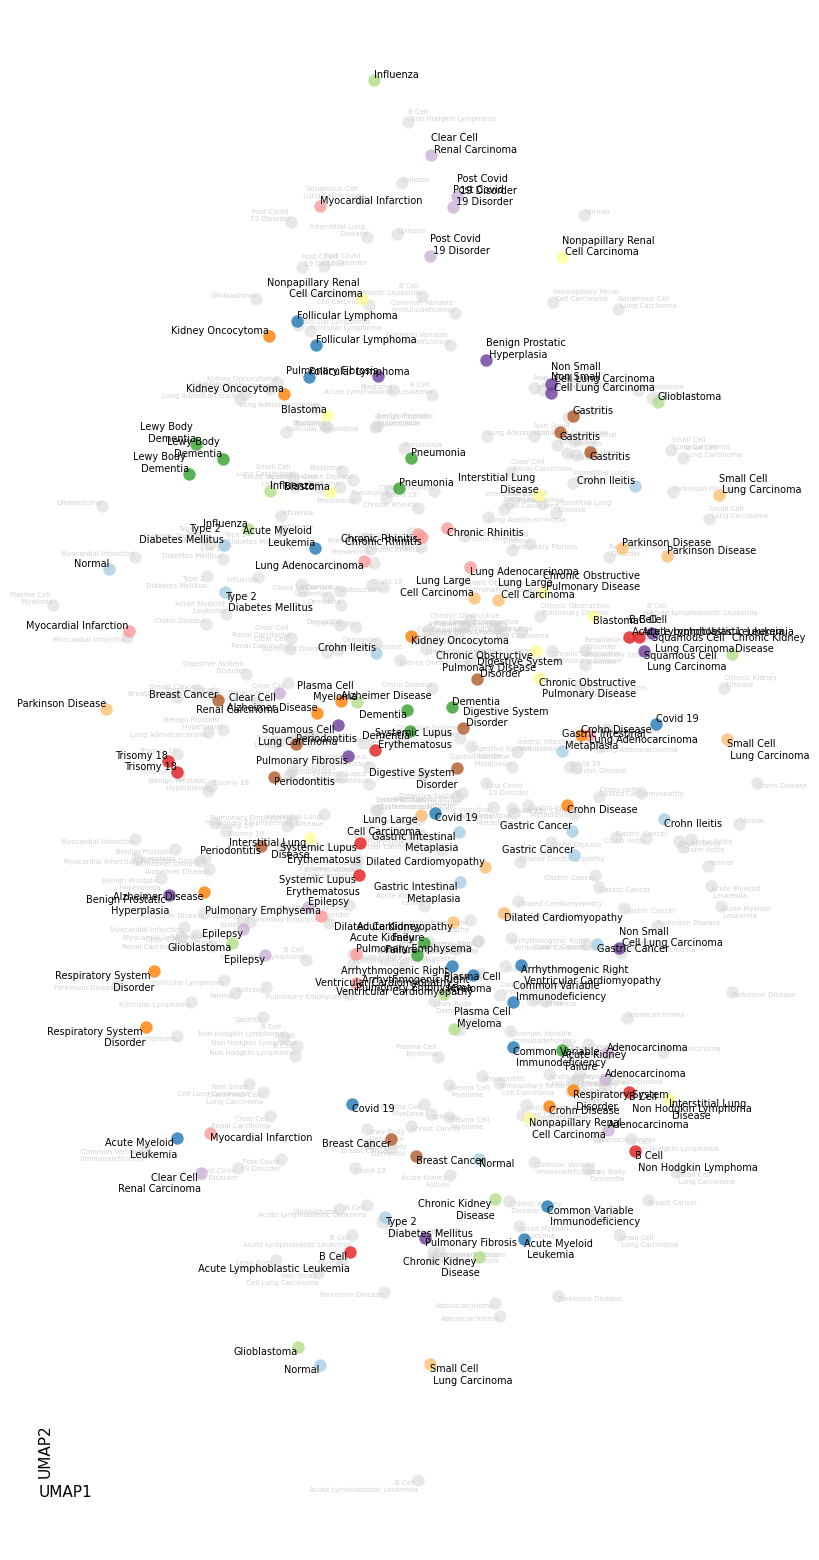

In [23]:
import matplotlib.pyplot as plt, seaborn as sns

def plot_landscape(df, figure_size=(10,20),
                   marker_size=40, save_path=None, alpha=0.7,
                   palette="Paired", lw=0, fontsize=12, fontweight='500', random_state=3):
    np.random.seed(9)
    diseases = ["Normal"] + np.random.choice([p for p in df['Phenotype'].unique() if p not in ["Normal"]],
                                             12, replace=False).tolist()
    diseases = df['Phenotype'].unique().tolist()
    palette_colors = sns.color_palette(palette, len(diseases))
    color_map = dict(zip(diseases, palette_colors))

    fig, ax = plt.subplots(figsize=figure_size, dpi=300 if SAVE else 100)
    scale=1
    used_bins = set()
    for disease in diseases:
        group = df[df['Phenotype']==disease]
        if len(group) == 0: 
            continue
        px, py = np.median(group['UMAP1']), np.median(group['UMAP2'])
        dist = np.sqrt((group['UMAP1']-px)**2 + (group['UMAP2']-py)**2)

        r = 50
        group_in_radius = group[dist <= r]

        sample = group_in_radius.sample(n=min(9, len(group_in_radius)), random_state=random_state)
        #display(group)
        #sample = group.sample(n=min(9,len(group)), random_state=random_state)
        color_points = sample.sample(n=min(3,len(sample)), random_state=random_state)
        grey_points = sample.drop(color_points.index)

        ax.scatter(grey_points['UMAP1'], grey_points['UMAP2'],
                   s=marker_size, c='lightgrey', alpha=0.5, lw=lw, zorder=-1)
        bins = np.floor(color_points[['UMAP1','UMAP2']].to_numpy()/scale).astype(int)
        mask = []
        for b in map(tuple, bins):
            if b not in used_bins:
                used_bins.add(b)
                mask.append(True)
            else:
                mask.append(False)
        unique_points = color_points[mask]
        #print(unique_points)
        ax.scatter(unique_points['UMAP1'], unique_points['UMAP2'],
               s=marker_size, c=[color_map[disease]], alpha=0.8, lw=lw)
        #ax.scatter(color_points['UMAP1'], color_points['UMAP2'],
        #           s=marker_size, c=[color_map[disease]], alpha=alpha, lw=lw)

        #px, py = np.median(sample['UMAP1']), np.median(sample['UMAP2'])
        if len(disease.split(' ')) > 2:
            disease = ' '.join(disease.split(' ')[:2] + ['\n'] + disease.split(' ')[2:])
        for _, row in unique_points.iterrows():
            ax.text(row['UMAP1'], row['UMAP2'], disease,
                    fontsize=fontsize-4, ha="left" if row['UMAP1'] > px else "right", va="bottom" if row['UMAP2'] > py else "top", color='black')
        for _, row in grey_points.iterrows():
            ax.text(row['UMAP1'], row['UMAP2'], disease,
                    fontsize=fontsize-6, ha="left" if row['UMAP1'] > px else "right", va="bottom" if row['UMAP2'] > py else "top", color='lightgrey', zorder=-1)

    # Optional cluster-level grey box annotations
    cluster_labels = {
        "Neurodegenerative": (-12, 38),
        "Respiratory": (33, -15),
        "Endocrine": (12, 3),
        "Metabolic": (15, -5),
        "Cardiovascular": (35, 20),
        "Oncological": (-5, -20),
        "Renal": (-5, 12),
    }
    cluster_labels = {}
    for label,(x,y) in cluster_labels.items():
        ax.text(x, y, label, fontsize=fontsize, ha="center", va="center",
                fontweight=fontweight, color='k',
                bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3'))

    for spine in ax.spines.values(): spine.set_visible(False)
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.set_xticks([]); ax.set_yticks([])
    #ax.get_legend().remove()
    x_min, x_max = df['UMAP1'].min(), df['UMAP1'].max()
    y_min, y_max = df['UMAP2'].min(), df['UMAP2'].max()
    x_margin = 0.01 * (x_max - x_min)
    y_margin = 0.005 * (y_max - y_min)
    #print(x_min, x_max, y_min, y_max)
    ax.text(x_min-x_margin, y_min, f'UMAP1', ha='left', va='top', fontsize=fontsize, fontweight=fontweight)
    ax.text(x_min-1.1*x_margin, y_min+y_margin, f'UMAP2', ha='left', va='bottom', rotation=90, fontsize=fontsize, fontweight=fontweight)

    if SAVE: plt.savefig("../figures/figure2_umap.svg", bbox_inches='tight', dpi=300, transparent=True)
    plt.show()

#df['UMAP2'] *= -1
plot_landscape(df, marker_size=80, random_state=4, fontsize=11)

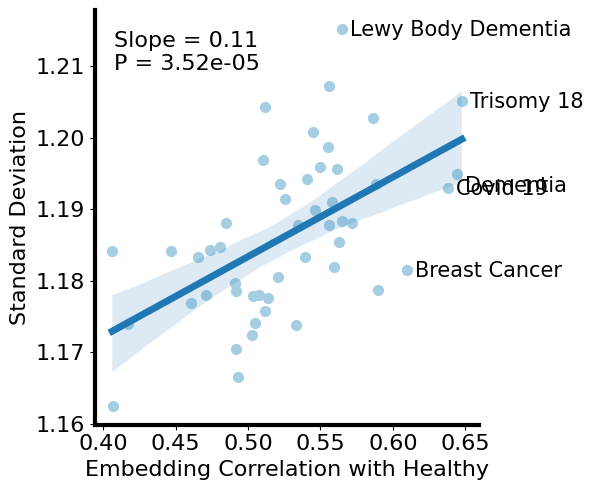

In [ ]:
from scipy.stats import pearsonr
analysis_df = pd.DataFrame(embedding_df.groupby('disease').apply(lambda group: pd.Series({"std": np.array(group['embeddings'].tolist()).std(),
                                                                                            "centroid": np.array(group['embeddings'].tolist()).mean(axis=0)}) ).reset_index())

normal_centroid = analysis_df[analysis_df['disease'] == '[normal]']['centroid'].values[0]
analysis_df['norm_normal'] = analysis_df['centroid'].apply(lambda x: np.linalg.norm(x-normal_centroid))
analysis_df['norm'] = analysis_df['centroid'].apply(lambda x: np.linalg.norm(x))
analysis_df['correlation'] = analysis_df['centroid'].apply(lambda x: pearsonr(x, normal_centroid)[0])
analysis_df = analysis_df[analysis_df['disease'] != "[normal]"]
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress
#sns.set_style("white")
#sns.set_context("paper", font_scale=1.8)
x = 'correlation'
slope, intercept, r_value, p_value, std_err = linregress(
    analysis_df[x], analysis_df["std"]
)
plt.figure(figsize=(6,5), dpi=300 if SAVE else 100)
palette = sns.color_palette("Paired", 2)
sns.regplot(
    data=analysis_df,
    x=x, 
    y="std",
    ci=95,         # bootstrap confidence interval
    n_boot=1000,   # number of bootstrap samples
    scatter_kws={"s": 50, "alpha": 1, "color": palette[0]}, 
    line_kws={"color": palette[1], "lw": 5, "zorder":10}
)
plt.text(
    0.05, 0.95,
    f"Slope = {slope:.2f}\nP = {p_value:.2e}",
    transform=plt.gca().transAxes,
    ha="left", va="top", fontsize=16, zorder=100,
)
subset = analysis_df[(analysis_df["correlation"] > 0.6) | (analysis_df["std"] > 1.21)]# 

lower_subset = analysis_df[(analysis_df["correlation"] < 0.403)]#
subset = pd.concat([subset, lower_subset])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
for _, row in subset.iterrows():
    offset_y = 0 if row['disease'] not in ['[dementia]'] else -8
    plt.annotate(
        ' '.join([w.capitalize() for w in  row["disease"][1:-1].split('_')]),
        (row["correlation"], row["std"]),
        xytext=(6,-5 +offset_y),
        textcoords="offset points",
        fontsize=15, zorder=20
    )

plt.xlabel("Embedding Correlation with Healthy", fontsize=16)
plt.ylabel("Standard Deviation", fontsize=16)
plt.gca().spines['left'].set_linewidth(3)
plt.gca().spines['top'].set_linewidth(0)
plt.gca().spines['right'].set_linewidth(0)
plt.gca().spines['bottom'].set_linewidth(3)
plt.tight_layout()
if SAVE: plt.savefig('../figures/figure2_healthy_correlation.svg', dpi=300, transparent=True)
plt.show()

(53, 4)


,precision,recall,f1,accuracy
[acute_kidney_failure],0.894253,0.7594,0.821328,0.993063
[acute_myeloid_leukemia],1.000000,0.7068,0.828217,0.993844
[alzheimer_disease],0.999799,0.9968,0.998297,0.999929
[b_cell_acute_lymphoblastic_leukemia],0.993381,0.9906,0.991989,0.999664
[b_cell_non_hodgkin_lymphoma],1.000000,0.9510,0.974885,0.998971


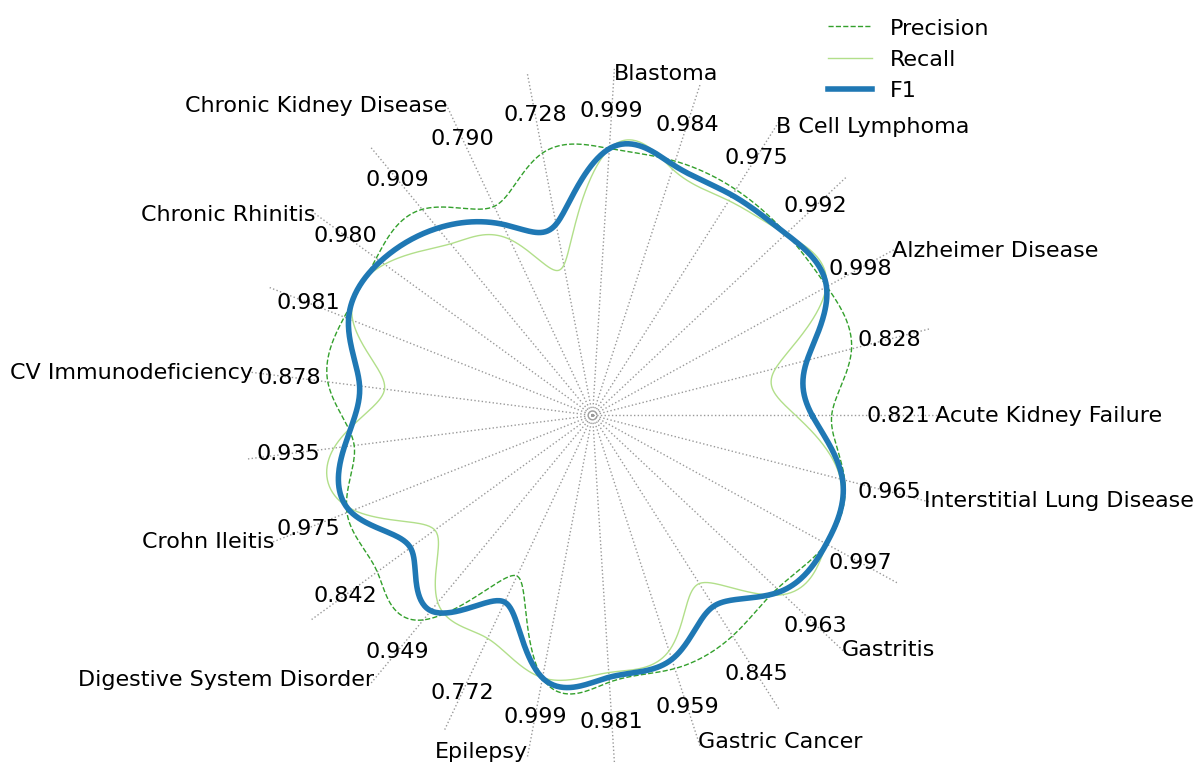

In [20]:
import pandas as pd
from scipy.interpolate import CubicSpline
import numpy as np, pandas as pd, matplotlib.pyplot as plt

esthetic_disease_labels = {'Arrhythmogenic Right Ventricular Cardiomyopathy': 'Arrhythmogenic Cardiomyopathy', 'Common Variable Immunodeficiency': 'CV Immunodeficiency', 
                           'B Cell Non Hodgkin Lymphoma': 'B Cell Lymphoma'}
def metrics_from_confusion(df, y_col="y", y_pred_col="y_pred"):
    labels = np.unique(np.concatenate([df[y_col], df[y_pred_col]]))
    cm = pd.crosstab(df[y_col], df[y_pred_col], rownames=["true"], colnames=["pred"], dropna=False).reindex(index=labels, columns=labels, fill_value=0).to_numpy()
    metrics = []
    for i, label in enumerate(labels):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FN + FP)
        precision = TP / (TP + FP) if TP + FP > 0 else 0
        recall = TP / (TP + FN) if TP + FN > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0
        acc = (TP + TN) / cm.sum()
        metrics.append([precision, recall, f1, acc])
    return pd.DataFrame(metrics, index=labels, columns=["precision","recall","f1","accuracy"])#.reset_index()


def radar_spline(df: pd.DataFrame, figsize=(9,9), radial_limits=None, label_radius_factor=1.06, samples=1000):
    n, d = df.shape
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)
    rmin = 0 if radial_limits is None else radial_limits[0]
    rmax = (np.nanmax(df.values) if radial_limits is None else radial_limits[1])
    fig, ax = plt.subplots(subplot_kw={"projection":"polar"}, figsize=figsize, dpi=300 if SAVE else 100)
    ax.set_ylim(rmin, 1.3*rmax)
    for ang in theta: ax.plot([ang, ang], [rmin, 1.3*rmax], lw=1, ls=":", color="0.6")
    #ax.plot(np.linspace(0,2*np.pi,512), np.full(512, 1), lw=2, ls="--", color="k")
    palette = sns.color_palette("Paired", 4)#['k' for _ in range(4)] #sns.color_palette("Set2", 4)
    styles = {'accuracy': {'color': palette[0], 'ls': '-', 'alpha':1}, 
                'f1': {'color': palette[1], 'ls': '-', 'alpha':1, 'lw':4},
                'recall': {'color': palette[2], 'ls': '-', 'alpha':1},
                'precision': {'color': palette[3], 'ls': '--', 'alpha':1}}
    for idx, (name, values) in enumerate(df.items()):
        if name =="accuracy": continue
        cs = CubicSpline(np.r_[theta, theta[0]+2*np.pi], np.r_[values.values, values.values[0]], bc_type="periodic")
        tt = np.linspace(0, 2*np.pi, samples, endpoint=False)
        ax.plot(tt, cs(tt), lw=styles[name].get('lw', 1), label=name.capitalize(), color=styles[name]['color'], ls=styles[name]['ls'], alpha=styles[name]['alpha'])
    ax.set_xticks([])
    ax.set_yticks([])
    fontsize = 16
    for idx, (ang, lbl) in enumerate(zip(theta, df.index.astype(str))):
        if idx % 2 == 1:continue # and df.loc[lbl, 'f1'] > 0.85: continue

        lbl =  ' '.join([w.capitalize() for w in  lbl[1:-1].split('_')])
        if (np.cos(ang) < 0): ha = "right"
        else: ha = 'left'
        ax.text(ang, rmax*1.28, esthetic_disease_labels.get(lbl, lbl), ha=ha, va="center" if lbl != "Dilated Cardiomyopathy" else "top",fontsize=fontsize)
    for ang, lbl in zip(theta, df['f1']):
        ax.text(ang, 1.08* rmax*label_radius_factor, f"{lbl:.3f}", ha="center", va="center",fontsize=fontsize)
    ax.legend(loc="upper right", bbox_to_anchor=(1.1, 1.1), frameon=False, fontsize=fontsize)
    ax.spines['polar'].set_visible(False)
    plt.tight_layout()
    if SAVE: plt.savefig('../figures/figure2_model_performance.svg', dpi=300, transparent=True)
    return fig, ax

metrics_by_disease = metrics_from_confusion(embedding_df, y_col='disease', y_pred_col='disease_pred')
print(metrics_by_disease.shape)
metrics_by_disease = metrics_by_disease[metrics_by_disease['f1'] > 0.7].head(25)
display(metrics_by_disease.head())
radar_spline(metrics_by_disease , figsize=(12,12))

plt.show()

## seed model variants experiment:

In [6]:
# Get representations
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm import tqdm
import sys
sys.path.append("../../../")
from polygene.eval.metrics import prepare_cell, test_batch
from polygene.model.model import load_trained_model
from polygene.data_utils.data_collators import collate_fn_wrapper
cell_data = sc.read_h5ad('/media/rohola/ssd_storage/primary/cxg_chunk2502.h5ad')

X = []
phene = 1
temperature = 1e-2
SEEDS_EXPERIMENT_PATH = "/media/lleger/LaCie/mit/disease_vector/seeds_experiment/"
for path in [SEEDS_EXPERIMENT_PATH + f"polygene_{idx}/" for idx in [0, 1, 2]]+ [SEEDS_EXPERIMENT_PATH + "../POLYGENE/"]:
    model, tokenizer = load_trained_model(path, checkpoint_n=3)
    tokenizer.bypass_inference = True

    output_representations = []
    for cell in tqdm(cell_data[:5000], path):
        prepared_cell = prepare_cell(cell, tokenizer)
        prepared_cell["labels"] = prepared_cell['input_ids'].detach().clone()
        prepared_cell["input_ids"][phene:phene+len(tokenizer.phenotypic_types)] = tokenizer.convert_tokens_to_ids(tokenizer.mask_token)
        del prepared_cell['str_labels']
        output = test_batch([prepared_cell], model, collate_fn_wrapper(tokenizer))
        output_representations.append(output.hidden_states[:, 0].detach().cpu().numpy())
    X.append(np.concatenate(output_representations))
pd.to_pickle(X, SEEDS_EXPERIMENT_PATH + 'representations.pkl')

AttributeError: 'DistilBertConfig' object has no attribute 'head_hidden_layers'

In [ ]:
# Process data

from sklearn.decomposition import TruncatedSVD
from sklearn.cross_decomposition import CCA
from scipy.spatial import procrustes
import numpy as np, pandas as pd
from sklearn.metrics import pairwise_distances

def cka_linear(X, Y):
    H = np.eye(X.shape[0]) - np.ones((X.shape[0], X.shape[0]))/X.shape[0]
    K = H @ (X @ X.T) @ H
    L = H @ (Y @ Y.T) @ H
    return np.sum(K*L)/np.sqrt(np.sum(K*K)*np.sum(L*L))

def mutual_knn(X, Y,):
    k = int(0.01*len(X))
    dist_x = pairwise_distances(X)
    dist_y = pairwise_distances(Y)
    nn_x = np.argsort(dist_x, axis=1)[:, 1:k+1]
    nn_y = np.argsort(dist_y, axis=1)[:, 1:k+1]
    overlap = [len(set(nn_x[i]) & set(nn_y[i])) / k for i in range(X.shape[0])]
    return np.mean(overlap)

X = pd.read_pickle(SEEDS_EXPERIMENT_PATH + "representations.pkl")[:-1]

print('Learned representations shape', [mat.shape for mat in X])
import itertools
procrustes_wrap = lambda x,y: 1 - procrustes(x,y)[2]

# We also tried procrustes and SVCCA but they don't accept harsher hypothesis perturbations. AKA Different matrix sizes dim=1 in X and Y
scores = []
for idx, (x_mat, y_mat) in enumerate(itertools.combinations(X, r=2)):
    s = []
    print("Combinations:\n", idx)
    #for n, func in zip([ 'Mutual kNN'], [ mutual_knn]):
    for n, func in zip(['CKA', 'Mutual kNN'], [cka_linear, mutual_knn]):
        value = func(x_mat, y_mat)
        print(n, round(func(x_mat, y_mat), 4))
        if n in ['CKA', 'Mutual kNN']: s.append(value)
    scores.append(s)

np.random.seed(3)
random_matrices = [np.random.uniform(size=X[0].shape) for _ in range(2)]
random_cka = cka_linear(random_matrices[0], random_matrices[1])
random_mknn = mutual_knn(random_matrices[0], random_matrices[1], )
baseline_performance = (2*random_cka*random_mknn)/(random_cka+random_mknn)
#baseline_performance=
print(baseline_performance, random_cka, random_mknn)

Learned representations shape [(5000, 256), (5000, 256), (5000, 256)]
Combinations:
 0
CKA 0.8917
Mutual kNN 0.773
Combinations:
 1
CKA 0.8881
Mutual kNN 0.768
Combinations:
 2
CKA 0.8904
Mutual kNN 0.775
0.0165048632452963 0.04880012745022704 0.009932000000000002


[0.8280934245688908, 0.8236782065427379, 0.8286954591403544]


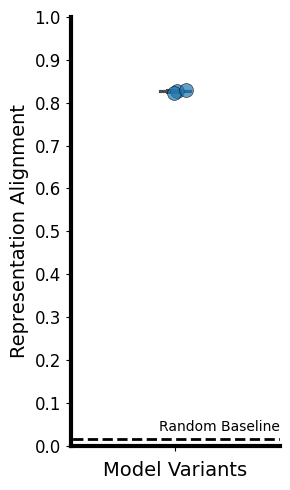

In [12]:
import matplotlib.pyplot as plt, seaborn as sns
fig,ax = plt.subplots(1,1, figsize=(3,5), dpi=300 if SAVE else 100)
fontsize=12
colors = sns.color_palette('Paired', 2)
harmonic_means = [s[0] for s in scores]
harmonic_means = [(2*s[0]*s[1])/(s[0] + s[1]) for s in scores]
print(harmonic_means)
np.random.seed(5)
ax.scatter(np.array([0]*len(harmonic_means)) + np.random.randn(len(harmonic_means))*0.02,
 harmonic_means, color=colors[1], s=100, alpha=0.7, edgecolors='k', linewidths=0.5)
ax.boxplot(harmonic_means)
box_color = (.30, .30, .30)
median_color = (.30, .30, .30)
box_linewidth = 1.5
bp = ax.boxplot(x=np.array(harmonic_means),positions=[0], showfliers=False,zorder=-3, boxprops=dict(color=box_color, linewidth=box_linewidth),
                whiskerprops=dict(color=box_color, linewidth=box_linewidth),
                capprops=dict(color=box_color, linewidth=box_linewidth),
                medianprops=dict(color=median_color, linewidth=box_linewidth, zorder=-4),)
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(0, 1)
ax.set_xticks([0], [""], fontsize=fontsize)
ax.set_yticks(np.linspace(0, 1, num=11), fontsize=fontsize)
ax.tick_params(axis='both', labelsize=fontsize)
ax.set_xlabel('Model Variants', fontsize=fontsize + 2)
ax.set_ylabel('Representation Alignment', fontsize=fontsize + 2)
ax.spines[['top', 'right']].set_linewidth(0)
ax.hlines(y=baseline_performance, xmin=-1, xmax=1, linestyles='--', color='k', lw=2)
ax.text(0.5, baseline_performance+0.01, "Random Baseline", 
        ha='right', va='bottom', fontsize=fontsize-2)
ax.spines[['bottom', 'left']].set_linewidth(3)
#ax.spines[['bottom', 'left']].set_color('0.8')
plt.tight_layout()
if SAVE:
    plt.savefig('../figures/figure2_representation_alignment.svg', transparent=True, dpi=300)
plt.show()

In [ ]:
# Statistical Test to see that alignment is significant
import numpy as np
from tqdm import tqdm

def combined_metric(X, Y):
    cka = cka_linear(X, Y)
    mknn = mutual_knn(X, Y)
    if mknn > 0 and cka > 0:
        return 2 * (cka * mknn) / (cka + mknn)
    else:
        return 0.0

def baseline_test(X, Y, repeats=1000, rng=None):
    rng = np.random.default_rng(rng)
    obs = combined_metric(X, Y)
    null_scores = []
    for _ in tqdm(range(repeats)):
        Y_perm = Y[rng.permutation(Y.shape[0])]
        null_scores.append(combined_metric(X, Y_perm))
    
    null_scores = np.array(null_scores)
    z = (obs - null_scores.mean()) / null_scores.std()
    return obs, z, null_scores, null_scores.mean(), null_scores.std()

obs, z, null, mean_null, std_null = baseline_test(X[0], X[1])
print("Observed:", obs)
print("Null mean:", mean_null)
print("Null std:", std_null)
print("Z-score:", z)
print("p_value:", (np.sum(null >= obs) + 1) / (len(null) + 1))

100%|██████████| 1000/1000 [03:07<00:00,  5.32it/s]

Observed: 0.8235375078952227
Null mean: 0.01641797628381226
Null std: 0.0015823927421290019
Z-score: 510.06271080685445
p_value: 0.000999000999000999
